## Randomized Search with Scikit-Optimize

In this notebook, we will perform **Randomized Search** to select the best **hyperparameters** for a Gradient Boosting Classifier, using the open source Python package [Scikit-Optimize](https://scikit-optimize.readthedocs.io/en/latest/).

The randomized search is performed with the class [dummy_minimize](https://scikit-optimize.readthedocs.io/en/latest/modules/minimize_functions.html#skopt.dummy_minimize).


### Procedure

To tune the hyper-parameters of our model we need to:

- define a model
- decide which parameters to optimize
- define the objective function we want to minimize.

### NOTE

Scikit-Optimize will always **minimize** the objective function, so if we want to maximize a function, for example the roc-auc, we need to **negate** the metric. Thus, instead of maximizing the roc-auc, we minimize the -roc-auc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split

from skopt import dummy_minimize # for the randomized search

# for the analysis
from skopt.plots import (
    plot_convergence,
    plot_evaluations,
)

from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

In [2]:
# load dataset

breast_cancer_X, breast_cancer_y = load_breast_cancer(return_X_y=True)
X = pd.DataFrame(breast_cancer_X)
y = pd.Series(breast_cancer_y).map({0:1, 1:0})

X.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# the target:
# percentage of benign (0) and malign tumors (1)

y.value_counts() / len(y)

0    0.627417
1    0.372583
Name: count, dtype: float64

In [4]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((398, 30), (171, 30))

## Define the Hyperparameter Space

Scikit-optimize provides an utility function to create the range of values to examine for each hyperparameters. More details in [skopt.Space](https://scikit-optimize.readthedocs.io/en/latest/modules/space.html)

In [5]:
# determine the hyperparameter space

param_grid = [
    Integer(10, 120, name="n_estimators"),
    Integer(1, 5, name="max_depth"),
    Real(0.0001, 0.1, prior='log-uniform', name='learning_rate'),
    Real(0.001, 0.999, prior='log-uniform', name="min_samples_split"),
    Categorical(['log_loss', 'exponential'], name="loss"),
]

# Scikit-optimize parameter grid is a list
type(param_grid)

list

## Define the model

In [6]:
# set up the gradient boosting classifier

gbm = GradientBoostingClassifier(random_state=0)

## Define the objective function

This is the hyperparameter response space, the function we want to minimize.

In [7]:
# We design a function to maximize the accuracy, of a GBM,
# with cross-validation

# the decorator allows our objective function to receive the parameters as
# keyword arguments. This is a requirement for scikit-optimize.

@use_named_args(param_grid)
def objective(**params):
    
    # model with new parameters
    gbm.set_params(**params)

    # optimization function (hyperparam response function)
    value = np.mean(
        cross_val_score(
            gbm, 
            X_train,
            y_train,
            cv=3,
            n_jobs=-4,
            scoring='accuracy')
    )

    # negate because we need to minimize
    return -value

## Randomized Search

In [8]:
# dummy_minimize performs the randomized search

search = dummy_minimize(
    objective,  # the objective function to minimize
    param_grid,  # the hyperparameter space
    n_calls=50,  # the number of evaluations of the objective function
    random_state=0,
)

In [9]:
# function value at the minimum.
# note that it is the negative of the accuracy

"Best score=%.4f" % search.fun

'Best score=-0.9523'

In [10]:
print("""Best parameters:
=========================
- n_estimators = %d
- max-depth = %d
- min_samples_split = %.3f
- learning_rate = %.3f
- loss = %s""" % (search.x[0], 
                search.x[1],
                search.x[2],
                search.x[3],
                search.x[4],
               ))

Best parameters:
- n_estimators = 117
- max-depth = 2
- min_samples_split = 0.094
- learning_rate = 0.004
- loss = exponential


## Evaluate convergence of the search

[plot_convergence](https://scikit-optimize.readthedocs.io/en/latest/modules/generated/skopt.plots.plot_convergence.html#skopt.plots.plot_convergence)

<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

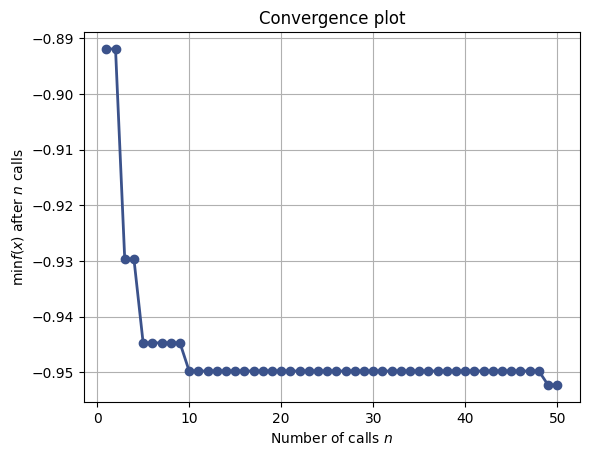

In [11]:
plot_convergence(search)

A good value is found approximately after 10 iterations, but we need the 50 to find the minimum. This is because the search is at random.

## Evaluation order

[plot_evaluations](https://scikit-optimize.readthedocs.io/en/latest/modules/generated/skopt.plots.plot_evaluations.html#skopt.plots.plot_evaluations)

In [12]:
dim_names = ['n_estimators', 'max_depth', 'min_samples_split', 'learning_rate', 'loss']

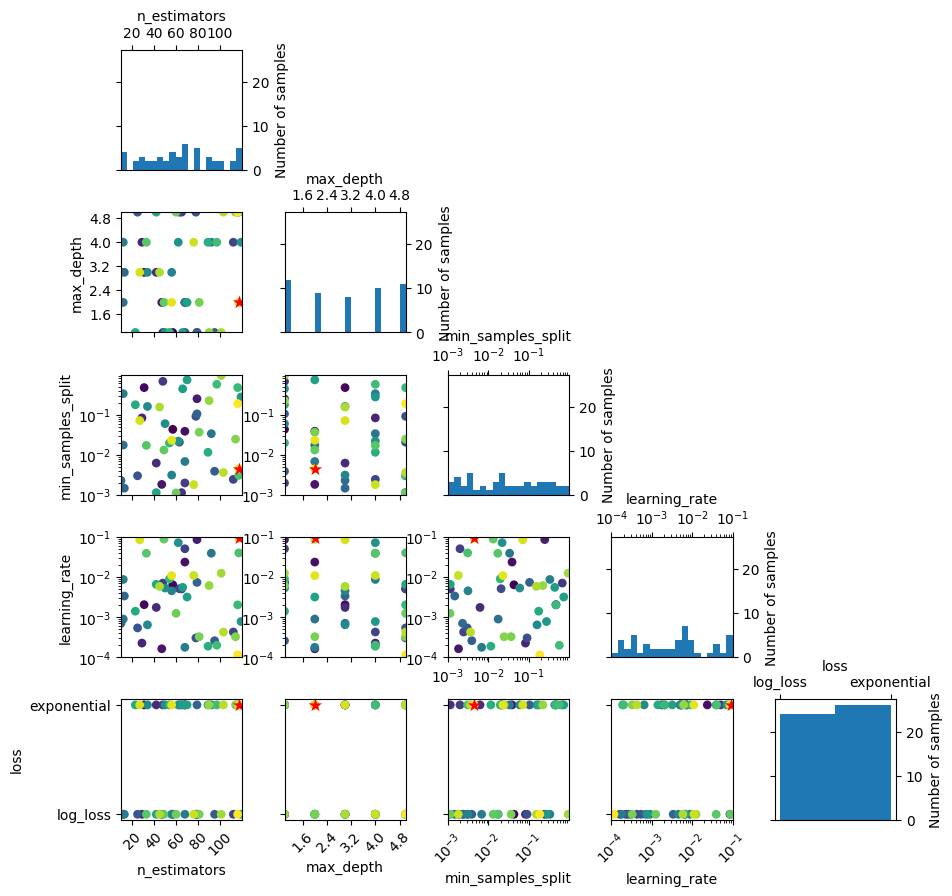

In [13]:
plot_evaluations(result=search, plot_dims=dim_names)
plt.show()

Because the search is done at random, we see an even distribution of dots and colours in the entire space, and also a uniform distribution in th histograms in the diagonal.

## The search class

In [14]:
# all together in one dataframe, so we can investigate further

tmp = pd.concat([
    pd.DataFrame(search.x_iters),
    pd.Series(search.func_vals),
], axis=1)

tmp.columns = dim_names + ['accuracy']

tmp.sort_values(by='accuracy', ascending=True, inplace=True)

tmp.head()

,n_estimators,max_depth,min_samples_split,learning_rate,loss,accuracy
48,117,2,0.093544,0.004473,exponential,-0.952267
9,68,1,0.050938,0.001985,exponential,-0.949761
19,92,4,0.039383,0.033627,exponential,-0.947273
25,62,4,0.072152,0.021937,exponential,-0.944748
4,79,1,0.086269,0.249533,log_loss,-0.944710


In [15]:
tmp.sort_values(by='n_estimators', ascending=False, inplace=True)

tmp.head()

,n_estimators,max_depth,min_samples_split,learning_rate,loss,accuracy
26,119,4,0.000780,0.276083,log_loss,-0.625636
48,117,2,0.093544,0.004473,exponential,-0.952267
35,117,5,0.040214,0.003072,exponential,-0.919648
33,116,5,0.002030,0.473568,exponential,-0.625636
49,116,5,0.000115,0.188281,log_loss,-0.625636
